In [1]:
from readers.NSIDataReader import NSIDataReader
from cil.processors import Slicer
import math
from pathlib import Path, PureWindowsPath
from cil.framework import AcquisitionData, AcquisitionGeometry, ImageGeometry
from cil.utilities.display import show2D, show_geometry, show_system_positions
print(NSIDataReader)

<class 'readers.NSIDataReader.NSIDataReader'>


In [2]:
def convert_value(s: str):
    """Try to convert a string to int, float, bool; otherwise return as string."""
    s = s.strip()
    if s.lower() == "true":
        return True
    if s.lower() == "false":
        return False
    # int?
    try:
        return int(s)
    except ValueError:
        pass
    # float?
    try:
        return float(s)
    except ValueError:
        pass
    return s

def parse_custom_text(text):
    lines = [line.rstrip() for line in text.splitlines() if line.strip()]
    root = {}
    stack = [(root, None)]  # (current_dict, current_key)
    
    for line in lines:
        indent = len(line) - len(line.lstrip())
        content = line.strip()
        
        # Adjust stack based on indentation
        while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
            stack.pop()
        
        current_dict, current_key = stack[-1]
        
        if content.startswith("</"):  # closing tag
            continue
        
        if content.startswith("<") and ">" in content:
            # Extract tag and value
            tag = content[1:content.find(">")]
            value = content[content.find(">")+1:].strip()
            
            if value:  # tag with value
                current_dict[tag] = value
            else:  # tag without value (container)
                if tag in current_dict:
                    # Convert to list if repeated
                    if not isinstance(current_dict[tag], list):
                        current_dict[tag] = [current_dict[tag]]
                    new_dict = {}
                    current_dict[tag].append(new_dict)
                else:
                    new_dict = {}
                    current_dict[tag] = new_dict
                stack.append((new_dict, tag))
    
    return root

In [3]:
parameter_file = '/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Demo_BabeRuth - PreReconstruction.nsipro'
with open(parameter_file) as f:
    text = f.read()

cfg = parse_custom_text(text)


In [4]:
reader = NSIDataReader(
    file_name='/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Demo_BabeRuth - PreReconstruction.nsipro',
    roi={'angle': -1, 'horizontal': -1, 'vertical': -1},
    normalise=True,
    fliplr=False,
    mode='bin'
)


In [5]:
import numpy as np
from cil.framework import AcquisitionGeometry

def build_nsi_helical_geometry(cfg):

    vortex = cfg["NSI Reconstruction Project"]["VorteX"]
    obj_rad = cfg["NSI Reconstruction Project"]["Object Radiograph"]
    setup = cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Setup"]
    det = cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Detector"]
    corr = cfg["NSI Reconstruction Project"]["Geometry Correction Steps"]

    # === Extract parameters ===
    height_total = float(vortex["height"])
    pitch = float(vortex["pitch"])
    revolutions = int(vortex["revolutions"])
    N = int(obj_rad["number"])
    angle_step_deg = float(obj_rad["angleStep"])

    pixel_pitch_x, pixel_pitch_y = map(float, obj_rad["pitch"].split())
    Ny = int(det["height pixels"])
    Nx = int(det["width pixels"])

    FDD = float(setup["source to detector distance"])   # detector distance from source
    FOD = float(setup["source to table distance"])      # source distance from rotation axis

    center_y_offset = float(corr["center"].split()[1])

    # Compute arrays
    angles = np.arange(N) * np.deg2rad(angle_step_deg)

    z_positions = np.linspace(0, height_total, N)

    # Source positions
    source_pos = np.zeros((N, 3), dtype=float)
    source_pos[:, 0] = FOD * np.cos(angles)
    source_pos[:, 1] = center_y_offset
    source_pos[:, 2] = FOD * np.sin(angles) + z_positions

    # Detector centers
    det_pos = np.zeros((N, 3), dtype=float)
    det_x = np.zeros((N, 3), dtype=float)
    det_y = np.zeros((N, 3), dtype=float)

    up = np.array([0, 1, 0], float)

    for i in range(N):
        s = source_pos[i]
        obj_centre = np.array([0, center_y_offset, z_positions[i]])

        ray = obj_centre - s
        ray_unit = ray / np.linalg.norm(ray)

        # Detector centre
        det_pos[i] = s + ray_unit * FDD

        # Detector basis
        x_dir = np.cross(ray_unit, up)
        x_dir /= np.linalg.norm(x_dir)

        y_dir = np.cross(x_dir, ray_unit)
        y_dir /= np.linalg.norm(y_dir)

        det_x[i] = x_dir
        det_y[i] = y_dir

    # Build CIL geometry
    ag = AcquisitionGeometry.create_Cone3D_Flex(
        source_position_set=source_pos,
        detector_position_set=det_pos,
        detector_direction_x_set=det_x,
        detector_direction_y_set=det_y,
        volume_centre_position=[0, center_y_offset, height_total/2],
        units='mm',
    )

    # Set detector panel
    ag.set_panel(num_pixels=[Nx, Ny],
                 pixel_size=[pixel_pitch_x, pixel_pitch_y])

    # Set labels to CIL convention
    ag.set_labels(['projection','vertical', 'horizontal'])

    return ag





def build_nsi_helical_geometry_debug(cfg):

    vortex = cfg["NSI Reconstruction Project"]["VorteX"]
    obj_rad = cfg["NSI Reconstruction Project"]["Object Radiograph"]
    setup = cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Setup"]
    det = cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Detector"]
    corr = cfg["NSI Reconstruction Project"]["Geometry Correction Steps"]

    # === Extract parameters ===
    height_total = float(vortex["height"])
    pitch = float(vortex["pitch"])
    revolutions = int(vortex["revolutions"])
    N = int(obj_rad["number"])
    angle_step_deg = float(obj_rad["angleStep"])

    pixel_pitch_x, pixel_pitch_y = map(float, obj_rad["pitch"].split())
    Ny = int(det["height pixels"])
    Nx = int(det["width pixels"])

    FDD = float(setup["source to detector distance"])
    FOD = float(setup["source to table distance"])

    center_y_offset = float(corr["center"].split()[1])

    # Compute arrays
    angles = np.arange(N) * np.deg2rad(angle_step_deg)
    z_positions = np.linspace(0, height_total, N)

    # Source positions
    source_pos = np.zeros((N, 3), dtype=float)
    source_pos[:, 0] = FOD * np.cos(angles)
    source_pos[:, 1] = center_y_offset
    source_pos[:, 2] = FOD * np.sin(angles) + z_positions

    # Detector centres + axes
    det_pos = np.zeros((N, 3), float)
    det_x = np.zeros((N, 3), float)
    det_y = np.zeros((N, 3), float)

    up = np.array([0, 1, 0], float)

    for i in range(N):
        s = source_pos[i]
        obj_centre = np.array([0, center_y_offset, z_positions[i]])

        ray = obj_centre - s
        ray_unit = ray / np.linalg.norm(ray)

        det_pos[i] = s + ray_unit * FDD

        x_dir = np.cross(ray_unit, up)
        x_dir /= np.linalg.norm(x_dir)
        y_dir = np.cross(x_dir, ray_unit)
        y_dir /= np.linalg.norm(y_dir)

        det_x[i] = x_dir
        det_y[i] = y_dir

    # Build CIL geometry
    ag = AcquisitionGeometry.create_Cone3D_Flex(
        source_position_set=source_pos,
        detector_position_set=det_pos,
        detector_direction_x_set=det_x,
        detector_direction_y_set=det_y,
        volume_centre_position=[0, center_y_offset, height_total/2],
        units='mm',
    )

    ag.set_panel(
        num_pixels=[Nx, Ny],
        pixel_size=[pixel_pitch_x, pixel_pitch_y]
    )

    ag.set_labels(['vertical', 'projection', 'horizontal'])

    # return geometry + all debug arrays
    return ag, source_pos, det_pos, det_x, det_y


In [6]:
ag, source_pos, det_pos, det_x, det_y = build_nsi_helical_geometry_debug(cfg)

In [7]:
print(source_pos)

[[2.57047000e+02 4.17065177e-02 0.00000000e+00]
 [2.57007905e+02 4.17065177e-02 4.52468237e+00]
 [2.56890631e+02 4.17065177e-02 9.04800108e+00]
 ...
 [2.55640822e+02 4.17065177e-02 1.53196887e+02]
 [2.56070215e+02 4.17065177e-02 1.57701129e+02]
 [2.56421715e+02 4.17065177e-02 1.62212181e+02]]


In [8]:
with open(parameter_file) as f:
    text = f.read()

cfg = parse_custom_text(text)

#problem. it thinks that series is the start of a new tag

In [9]:
print(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Detector']['serial'])

{}


In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection


def plot_3d_points(points, title="3D Points"):
    """
    points: (N, 3) array-like of [x, y, z] points
    """

    pts = np.asarray(points)
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, s=4)
    ax.plot(x, y, z, linewidth=1)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)

    # --- equal axis scaling ---
    max_range = np.array([x.max()-x.min(),
                          y.max()-y.min(),
                          z.max()-z.min()]).max() / 2.0

    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()


In [11]:
def tangent_plane_vectors(point):
    """
    Given a point on a sphere, returns two orthonormal vectors that span
    the tangent plane at that point.
    """
    point = np.array(point, dtype=np.float32)
    normal = point / np.linalg.norm(point)  # Normalize to get the normal vector

    # Choose a vector not parallel to the normal
    if not np.allclose(normal[:2], [0, 0]):
        v1 = np.array([-normal[1], normal[0], 0])
    else:
        v1 = np.array([1, 0, 0])

    v1 = v1 / np.linalg.norm(v1)  # Normalize v1
    v2 = np.cross(normal, v1)     # v2 is orthogonal to both normal and v1

    return v1, v2

def helical_points(radius, angle_step, pitch, num_steps_per_rev, num_revolutions=1, mirrored=False):
    """
    Generate points along a helical path, with optional mirroring.

    Parameters:
        radius (float): Radius of the helix.
        angle_step (float): Step size in radians for each point.
        pitch (float): Z movement per full rotation.
        num_steps_per_rev (int): Number of steps per revolution.
        num_revolutions (int): Total number of revolutions.
        mirrored (bool): If True, start at 180° offset.

    Returns:
        list of tuples: [(x, y, z), ...]
    """
    points = []
    total_steps = num_steps_per_rev * num_revolutions
    offset = math.pi if mirrored else 0  # 180° offset for mirrored helix
    for i in range(total_steps):
        theta = i * angle_step + offset
        x = radius * math.cos(theta)
        y = radius * math.sin(theta)
        z = (pitch / (2 * math.pi)) * (theta - offset)  # keep Z aligned with original
        points.append((x, y, z))
    return points

In [12]:
#   Copyright 2025 UKRI-STFC
#   Copyright 2025 University of Manchester

#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at

#   http://www.apache.org/licenses/LICENSE-2.0

#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
#
# Authors:
# Evan Kiely (WMG)

from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.io.TIFF import TIFFStackReader
import warnings
import numpy as np
import os
    
        
class NSIDataReader_(object):
    
    def __init__(self, file_name=None, roi=None, num_proj_subset=None):
        """
        file_name: Should be in the file format .nsipro
        num_proj_subset: number of projections to use starting from the first projection.
            TODO - Extend this to a slice object.
        """
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        
        if file_name is not None:
            self.set_up(file_name=file_name, num_proj_subset=num_proj_subset, roi=roi)
        self.roi = roi
    
    @staticmethod
    def parse_nsipro(file_name):
        with open(file_name, 'r') as f:
            text = f.read()
        lines = [line.rstrip() for line in text.splitlines() if line.strip()]
        root = {}
        stack = [(root, None)]  # (current_dict, current_key)
        
        for line in lines:
            indent = len(line) - len(line.lstrip())
            content = line.strip()
            
            # Adjust stack based on indentation
            while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
                stack.pop()
            
            current_dict, current_key = stack[-1]
            
            if content.startswith("</"):  # closing tag
                continue
            
            if content.startswith("<") and ">" in content:
                # Extract tag and value
                tag = content[1:content.find(">")]
                value = content[content.find(">")+1:].strip()
                
                if value:  # tag with value
                    current_dict[tag] = value
                else:  # tag without value (container)
                    if tag in current_dict:
                        # Convert to list if repeated
                        if not isinstance(current_dict[tag], list):
                            current_dict[tag] = [current_dict[tag]]
                        new_dict = {}
                        current_dict[tag].append(new_dict)
                    else:
                        new_dict = {}
                        current_dict[tag] = new_dict
                    stack.append((new_dict, tag))
        
        return root
            
    def set_up(self,
                file_name=None,
                  num_proj_subset=None,
                  roi={'projection': -1, 'horizontal': -1, 'vertical': -1},):
        self._metadata = self.parse_nsipro(file_name)['NSI Reconstruction Project']
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.tiff_directory_path = (Path(file_name).parent / PureWindowsPath(self._metadata['Object Radiograph']['file'])).parent

        if self.file_name == None:
            raise Exception('Path to file is required.')
        
        if not(os.path.isfile(self.file_name)):
            raise Exception('File\n {}\n does not exist.'.format(self.file_name))
        
        self._height_per_rev = float(self._metadata['VorteX']['pitch'])
        self._revs = int(self._metadata['VorteX']['revolutions'])
        self._num_proj = int(self._metadata['Object Radiograph']['number'])
        self._angle_step = self._num_proj / (360 * self._revs)
        self._proj_per_rev = self._num_proj / self._revs
        self._height_per_step = self._height_per_rev / self._proj_per_rev


        self._pixel_num_w = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['width pixels'])
        self._pixel_num_h = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['height pixels'])
        microns_to_mm = 0.001
        self._pixel_size_w = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
        self._pixel_size_h = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])
        self._src_to_det = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
        self._src_to_obj = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])
        self._obj_to_det = self._src_to_obj - self._src_to_det

        self.N = self._num_proj
        self._src_pos = np.zeros((self.N,3))
        self._det_pos = np.zeros((self.N,3))
        self._det_x = np.zeros((self.N,3))
        self._det_y = np.zeros((self.N,3))

        def get_rot_mat(ang):
            ang_rad = np.deg2rad(ang)
            c = np.cos(ang_rad)
            s = np.sin(ang_rad)
            Rz = np.array([
                [ c, -s, 0],
                [ s,  c, 0],
                [ 0,  0, 1]
            ])
            return Rz

        self._src_pos[0] = [self._src_to_obj, 0., 0.]
        self._det_pos[0] = [self._obj_to_det, 0., 0.]
        self._det_x[0] = [0., 1, 0]
        self._det_y[0] = [0., 0., 1]
        for i in range(1,self.N):
            h = i * self._height_per_step
            Rz = get_rot_mat(self._angle_step)
            
            self._src_pos[i] = Rz @ self._src_pos[i-1]
            self._det_pos[i] = Rz @ self._det_pos[i-1]
            self._det_x[i] = Rz @ self._det_x[i-1]
            self._det_y[i] = Rz @ self._det_y[i-1]

            self._src_pos[i,2] = h
            self._det_pos[i,2] = h
        
        self._ag = AcquisitionGeometry.create_Cone3D_Flex(self._src_pos, self._det_pos, self._det_x, self._det_y)
        self._ag = self._ag.set_panel((self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h))
        self._ag.set_labels(['projection','vertical', 'horizontal'])


        N_full  = int(self._metadata["Object Radiograph"]["number"])
        Ny_full = int(self._metadata["CT Project Configuration"]["Technique Configuration"]["Detector"]["height pixels"])
        Nx_full = int(self._metadata["CT Project Configuration"]["Technique Configuration"]["Detector"]["width pixels"])
        self._roi_par = [
            [0, N_full, 1],     # projection
            [0, Ny_full, 1],    # vertical
            [0, Nx_full, 1]     # horizontal
        ]

        for key in roi.keys():
            if key == 'projection':
                idx = 0
            elif key == 'vertical':
                idx = 1
            elif key == 'horizontal':
                idx = 2
            if roi[key] != -1:
                for i in range(2):
                    if roi[key][i] != None:
                        if roi[key][i] >= 0:
                            self._roi_par[idx][i] = roi[key][i]
                        else:
                            self._roi_par[idx][i] = self._roi_par[idx][1]+roi[key][i]
                if len(roi[key]) > 2:
                    if roi[key][2] != None:
                        if roi[key][2] > 0:
                            self._roi_par[idx][2] = roi[key][2]
                        else:
                            raise Exception("Negative step is not allowed")
        
        print(self._roi_par)
        # -------------------------------
        # Build full geometry (unsliced)
        # -------------------------------
        print(roi)
        processor = Slicer(roi)
        processor.set_input(self._ag)
        geometry_sliced = processor.get_output()
        self._ag = geometry_sliced



    # def set_up(self,
    #        file_name=None,
    #        roi={'projection': -1, 'horizontal': -1, 'vertical': -1},
    #        normalise=True,
    #        mode='bin',
    #        fliplr=False):

    #     self.file_name = file_name
    #     self.roi = roi.copy()
    #     self.normalise = normalise
    #     self.mode = mode
    #     self.fliplr = fliplr

    #     if file_name is None:
    #         raise ValueError("Path to NSI file is required.")

    #     # -------------------------------
    #     # Load config
    #     # -------------------------------
    #     with open(self.file_name, "r") as f:
    #         text = f.read()
    #     cfg = parse_custom_text(text)
    #     self.cfg = cfg

    #     # -------------------------------
    #     # Read original size
    #     # -------------------------------
    #     N_full  = int(cfg["NSI Reconstruction Project"]["Object Radiograph"]["number"])
    #     Ny_full = int(cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Detector"]["height pixels"])
    #     Nx_full = int(cfg["NSI Reconstruction Project"]["CT Project Configuration"]["Technique Configuration"]["Detector"]["width pixels"])
    #     pitch = float(cfg['NSI Reconstruction Project']['VorteX']['pitch'])
    #     revolutions = int(cfg['NSI Reconstruction Project']['VorteX']['revolutions'])
    #     tiff_files = cfg['NSI Reconstruction Project']['Object Radiograph']['file']
    #     num_proj = int(cfg['NSI Reconstruction Project']['Object Radiograph']['number'])
    #     angle_step = float(cfg['NSI Reconstruction Project']['Object Radiograph']['angleStep'])
    #     detector_w = int(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Detector']['width pixels'])
    #     detector_h = int(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Detector']['height pixels'])
    #     pixel_w = int(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
    #     pixel_h = int(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])

    #     source_detector_distance = float(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
    #     source_table_distance = float(cfg['NSI Reconstruction Project']['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])
    #     points_source = helical_points(radius=source_table_distance, angle_step=math.radians(angle_step), pitch=pitch, num_steps_per_rev=360, num_revolutions=12)
    #     points_detector = helical_points(radius=source_detector_distance-source_table_distance, angle_step=math.radians(angle_step), pitch=pitch, num_steps_per_rev=360, num_revolutions=12, mirrored=True)
    #     x1, y1, z1 = zip(*points_source)
    #     x2, y2, z2 = zip(*points_detector)

    #     # -------------------------------
    #     # Initialise ROI table [proj, vert, horiz]
    #     # -------------------------------
    #     self._roi_par = [
    #         [0, N_full, 1],     # projection
    #         [0, Ny_full, 1],    # vertical
    #         [0, Nx_full, 1]     # horizontal
    #     ]

    #     for key in roi.keys():
    #             if key == 'projection':
    #                 idx = 0
    #             elif key == 'vertical':
    #                 idx = 1
    #             elif key == 'horizontal':
    #                 idx = 2
    #             if roi[key] != -1:
    #                 for i in range(2):
    #                     if roi[key][i] != None:
    #                         if roi[key][i] >= 0:
    #                             self._roi_par[idx][i] = roi[key][i]
    #                         else:
    #                             self._roi_par[idx][i] = self._roi_par[idx][1]+roi[key][i]
    #                 if len(roi[key]) > 2:
    #                     if roi[key][2] != None:
    #                         if roi[key][2] > 0:
    #                             self._roi_par[idx][2] = roi[key][2]
    #                         else:
    #                             raise Exception("Negative step is not allowed")
        
    #     print(self._roi_par)
    #     # -------------------------------
    #     # Build full geometry (unsliced)
    #     # -------------------------------
    #     full_ag = build_nsi_helical_geometry(cfg)
    #     processor = Slicer(roi)
    #     processor.set_input(full_ag)
    #     geometry_sliced = processor.get_output()
    #     self._ag = geometry_sliced



    def get_geometry(self, index=None):
        '''
        Return AcquisitionGeometry object.
        index=None returns the flex geometry
        while setting it to an integer returns the geometry at that specific angle.
        '''
        if index is None:
            return self._ag
        
        ag = AcquisitionGeometry.create_Cone3D(
            self._src_pos[index],
            self._det_pos[index],
            self._det_x[index],
            self._det_y[index],
        ).set_panel(
            (self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h)
        ).set_angles([index*self._angle_step])
        return ag
    
    def get_roi(self):
        '''returns the roi'''
        roi = self._roi_par[:]
        if self._ag.dimension == '2D':
            roi.pop(1)

        roidict = {}
        for i,el in enumerate(roi):
            # print (i, el)
            roidict['axis_{}'.format(i)] = tuple(el)
        return roidict

    def read(self):

        obj_rad = self._metadata["Object Radiograph"]

        raw_field = obj_rad["file"].replace("\\", "/")
        tiff_folder = raw_field.split("/")[0]

        cfg_dir = os.path.dirname(self.file_name)
        tiff_dir = os.path.join(cfg_dir, tiff_folder)

        roi = self.roi
        label_to_axis = {
            'vertical': 'axis_2',
            'projection': 'axis_0',
            'horizontal': 'axis_1'
        }
        roi_axis = {label_to_axis[k]: v for k, v in roi.items()}


        reader = TIFFStackReader()
        reader.set_up(
            file_name=tiff_dir,
            roi=roi_axis,   # MUST match geometry slicing
        )
        print(roi_axis)

        print(self._ag)
        ad = reader.read_as_AcquisitionData(self._ag)

        return ad
    


    def get_image_geometry(self):
        magnification = np.mean(self._ag.magnification)
        min_height = self._pixel_num_h // 2
        extra_height = int(self._height_per_step * self.N / self._pixel_size_w)
        pixel_height = min_height + extra_height
        ig = ImageGeometry(
            self._pixel_num_w, self._pixel_num_w, pixel_height*2, # voxel nums
            self._pixel_size_w/magnification, self._pixel_size_w/magnification, self._pixel_size_w/magnification, # voxel sizes
            center_z=0#self._pixel_size_w * extra_height / 2
        )
        return ig



    def load_projections(self):
        '''alias of read for backward compatibility'''
        return self.read()




In [34]:
reader = NSIDataReader_(
    file_name='/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Demo_BabeRuth - PreReconstruction.nsipro',
    roi={'projection': (0,1080,1)},
)


[[0, 1080, 1], [0, 1536, 1], [0, 1536, 1]]
{'projection': (0, 1080, 1)}
New geometry:  Per-projection 3D Cone-beam tomography
System configuration:
	Number of projections: 1080
	Source positions 0-9: [[2.57047000e+02,0.00000000e+00,0.00000000e+00],
 [2.57007850e+02,4.48608872e+00,4.16968634e-02],
 [2.56890414e+02,8.97081093e+00,8.33937269e-02],
 [2.56694726e+02,1.34528005e+01,1.25090590e-01],
 [2.56420846e+02,1.79306923e+01,1.66787454e-01],
 [2.56068859e+02,2.24031222e+01,2.08484317e-01],
 [2.55638870e+02,2.68687279e+01,2.50181181e-01],
 [2.55131011e+02,3.13261491e+01,2.91878044e-01],
 [2.54545436e+02,3.57740281e+01,3.33574907e-01],
 [2.53882325e+02,4.02110099e+01,3.75271771e-01]]
	Detector positions 0-9: [[-1.00149300e+03, 0.00000000e+00, 0.00000000e+00],
 [-1.00134047e+03,-1.74784629e+01, 4.16968634e-02],
 [-1.00088292e+03,-3.49516017e+01, 8.33937269e-02],
 [-1.00012049e+03,-5.24140938e+01, 1.25090590e-01],
 [-9.99053413e+02,-6.98606202e+01, 1.66787454e-01],
 [-9.97682017e+02,-8.7285

In [35]:
ad = reader.read()

{'axis_0': (0, 1080, 1)}
Per-projection 3D Cone-beam tomography
System configuration:
	Number of projections: 1080
	Source positions 0-9: [[2.57047000e+02,0.00000000e+00,0.00000000e+00],
 [2.57007850e+02,4.48608872e+00,4.16968634e-02],
 [2.56890414e+02,8.97081093e+00,8.33937269e-02],
 [2.56694726e+02,1.34528005e+01,1.25090590e-01],
 [2.56420846e+02,1.79306923e+01,1.66787454e-01],
 [2.56068859e+02,2.24031222e+01,2.08484317e-01],
 [2.55638870e+02,2.68687279e+01,2.50181181e-01],
 [2.55131011e+02,3.13261491e+01,2.91878044e-01],
 [2.54545436e+02,3.57740281e+01,3.33574907e-01],
 [2.53882325e+02,4.02110099e+01,3.75271771e-01]]
	Detector positions 0-9: [[-1.00149300e+03, 0.00000000e+00, 0.00000000e+00],
 [-1.00134047e+03,-1.74784629e+01, 4.16968634e-02],
 [-1.00088292e+03,-3.49516017e+01, 8.33937269e-02],
 [-1.00012049e+03,-5.24140938e+01, 1.25090590e-01],
 [-9.99053413e+02,-6.98606202e+01, 1.66787454e-01],
 [-9.97682017e+02,-8.72858663e+01, 2.08484317e-01],
 [-9.96006717e+02,-1.04684524e+02, 

In [36]:
ag = reader.get_geometry()

In [37]:
ig = reader.get_image_geometry()
print(ig)

Number of channels: 1
channel_spacing: 1.0
voxel_num : x1536,y1536,z3336
voxel_size : x0.04084844343445576,y0.04084844343445576,z0.04084844343445576
center : x0,y0,z0



In [38]:
import tifffile
flat = tifffile.imread('/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Radiographs-Demo_BabeRuth/Demo_BabeRuth-radio_04319.tif')

In [ ]:
from cil.plugins.astra import FBP
ad_ = ad.as_array()
ad_ff_ = -np.log(ad_/(flat[None]+0.1))
ad_ff = AcquisitionData(ad_ff_, geometry=ag)


/zhome/71/c/146676/miniconda3/envs/cil/lib/python3.11/site-packages/cil/framework/data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


: 

In [40]:
ad_ff.reorder(order='astra')
fbp = FBP(image_geometry=ig, acquisition_geometry=ad_ff.geometry)
fbp.set_input(ad_ff)
recon = fbp.get_output()

: 

: 

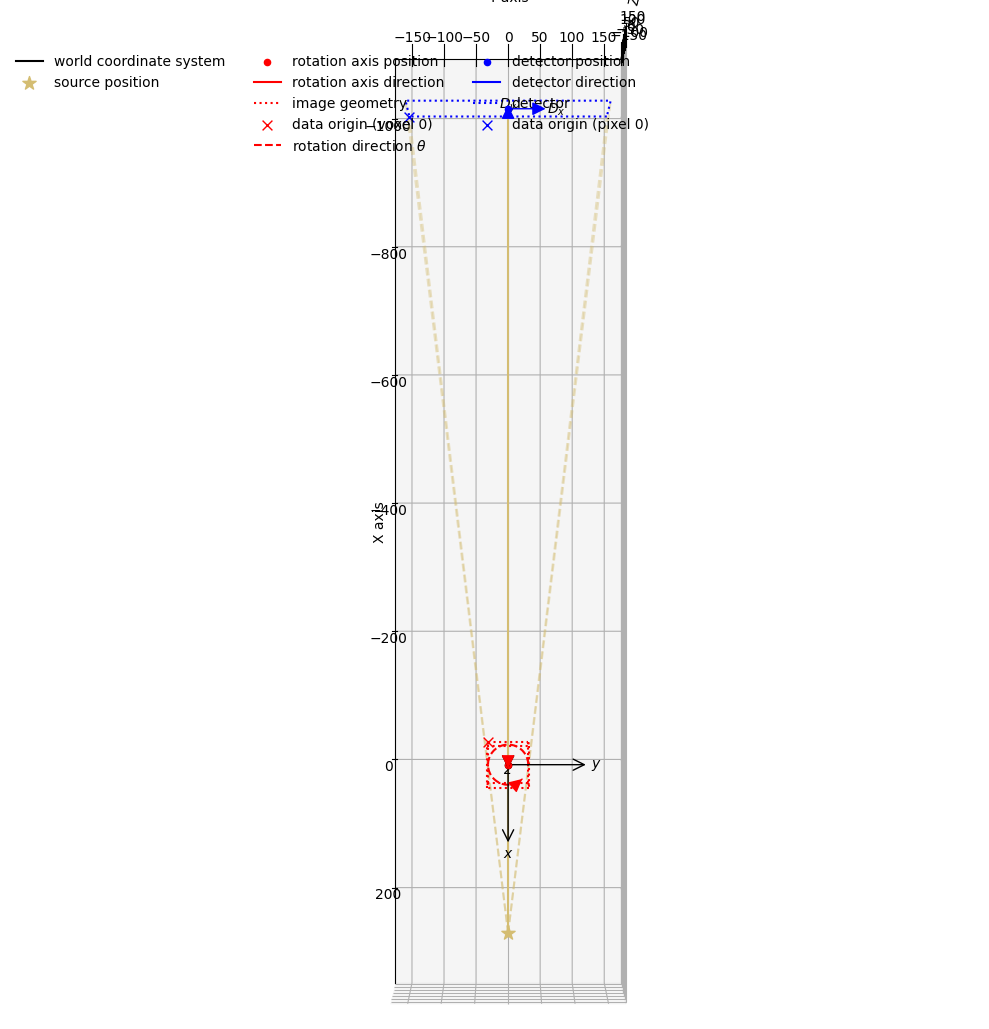

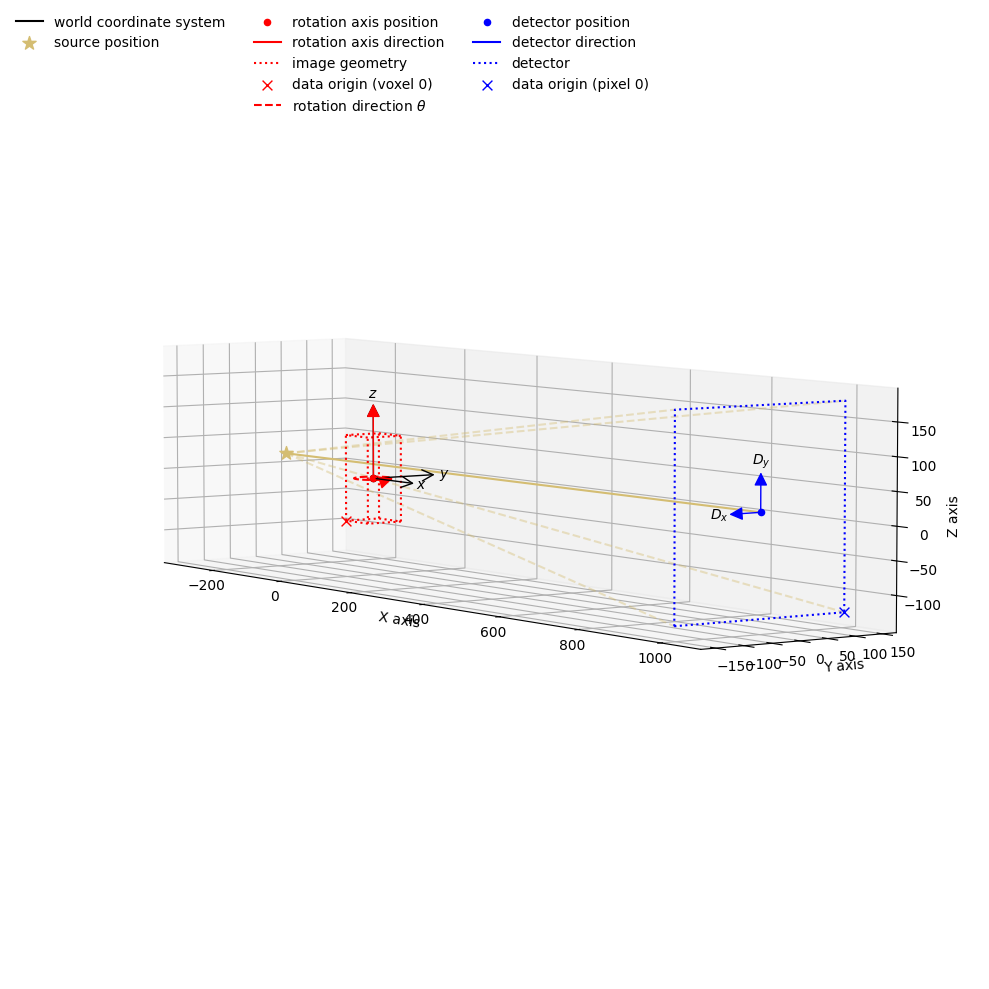

In [ ]:
show_geometry(reader.get_geometry(0), ig, grid=True, elevation=90, azimuthal = 0)
show_geometry(reader.get_geometry(540), ig, grid=True, elevation=5)

(3336, 1536, 1536)


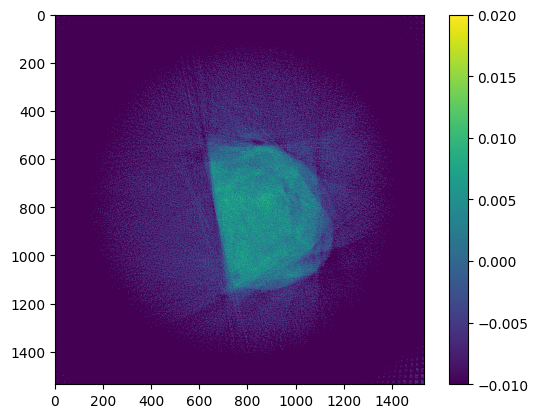

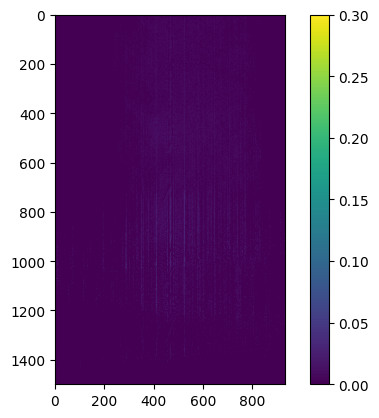

In [ ]:
print(recon.as_array().shape)

plt.imshow(recon.as_array()[2050])
plt.clim([-0.01,0.02])
plt.colorbar()
plt.show()

plt.imshow(recon.as_array()[1500:3000,300:-300,750])
plt.clim([0.0,0.3])
plt.colorbar()
plt.show()


In [ ]:
print(ag)

Per-projection 3D Cone-beam tomography
System configuration:
	Number of projections: 4320
	Source positions 0-9: [[2.57047000e+02,4.17065177e-02,0.00000000e+00],
 [2.57007905e+02,4.17065177e-02,4.52468237e+00],
 [2.56890631e+02,4.17065177e-02,9.04800108e+00],
 [2.56695215e+02,4.17065177e-02,1.35685929e+01],
 [2.56421715e+02,4.17065177e-02,1.80850953e+01],
 [2.56070215e+02,4.17065177e-02,2.25961473e+01],
 [2.55640822e+02,4.17065177e-02,2.71003893e+01],
 [2.55133666e+02,4.17065177e-02,3.15964637e+01],
 [2.54548901e+02,4.17065177e-02,3.60830158e+01],
 [2.53886707e+02,4.17065177e-02,4.05586933e+01]]
	Detector positions 0-9: [[-1.00149300e+03, 4.17065177e-02, 0.00000000e+00],
 [-1.00134068e+03, 4.17065177e-02,-1.74246282e+01],
 [-1.00088376e+03, 4.17065177e-02,-3.48439434e+01],
 [-1.00012239e+03, 4.17065177e-02,-5.22526341e+01],
 [-9.99056797e+02, 4.17065177e-02,-6.96453921e+01],
 [-9.97687301e+02, 4.17065177e-02,-8.70169142e+01],
 [-9.96014322e+02, 4.17065177e-02,-1.04361903e+02],
 [-9.940

In [ ]:
cfg["NSI Reconstruction Project"]["VorteX"]

{'height': '180.13045',
 'pitch': '15.0108708333333',
 'revolutions': '12',
 'sets': '3',
 'set height': '60.0434833333333',
 'revolutions per set': '4',
 'sigma': '50.0362361111111'}